In [ ]:
from pathlib import Path
from utils.results_manager import ResultsManager

In [16]:
%config InlineBackend.figure_format = 'retina'

In [12]:
import pandas as pd
import numpy as np
import mplhep
import matplotlib.pyplot as plt
from matplotlib import gridspec
from adjustText import adjust_text
mplhep.style.use("CMS")

def scatter_llr_vs_raw(df: pd.DataFrame):

    label_fontsize = 18
    tick_fontsize = 18
    legend_fontsize = 18

    """Scatter plot of mu_llr vs mu_raw, colored by rel_gain."""
    plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3})
    fig = plt.figure(figsize=(14, 12))
    gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1.1], height_ratios=[1.1, 4],
        wspace=0.05, hspace=0.05)

    ax_scatter = fig.add_subplot(gs[1,0])

    x = df['mu_raw'].values
    y = df['mu_llr'].values
    c = df['rel_gain'].values  # color by relative gain

    # main scatter, colored by rel_gain
    sc = ax_scatter.scatter(x, y, c=c, s=42, cmap='viridis', edgecolor='none')

    # 1: diagonal (LLR=raw) and gain line (LLR = 0.9 * raw)
    xmin, xmax = x.min()*0.95, x.max()*1.05
    xx = np.linspace(xmin, xmax, 200)
    ax_scatter.plot(xx, xx, linestyle='--', linewidth=1.2, color='0.35', label=r'$y=x$')

    # 3: annotate the top N improvers
    N_anno = 5
    top = df.sort_values('rel_gain', ascending=False).head(N_anno)
    texts = []
    for _, r in top.iterrows():
        texts.append(ax_scatter.text(r['mu_raw'], r['mu_llr'], r['name'],
                fontsize=12, color='black', alpha=0.9))

    for t in texts:
        if t.get_text() in ["all_sT", "blnu_pt"]:
            t.set_x(t.get_position()[0] - 200)  # move left

    adjust_text(texts, ax=ax_scatter,
        arrowprops=dict(arrowstyle='-', color='0.5', lw=0.5),
        expand_points=(1.2,1.2),   # repel from points
        expand_axes=(1.2,1.2)      # repel from axes
    )

    # labels, limits, legend, colorbar
    ax_scatter.set_xlabel(r'$\mu$ from raw observable', fontsize=label_fontsize)
    ax_scatter.set_ylabel(r'$\mu$ from $\mathrm{LLR}(x)$', fontsize=label_fontsize)
    ax_scatter.set_xlim(xmin, xmax)
    ymin, ymax = y.min()*0.95, y.max()*1.05
    ax_scatter.set_ylim(ymin, ymax)
    ax_scatter.tick_params(axis='both', labelsize=tick_fontsize)

    cb = fig.colorbar(sc, ax=ax_scatter, fraction=0.046, pad=0.04)
    cb.set_label(r'relative gain', fontsize=label_fontsize)

    plt.savefig('raw_vs_llr_scatter.pdf', dpi=300, bbox_inches='tight')
    plt.show()

def get_diagnostics_df(df: pd.DataFrame) -> pd.DataFrame:
    vars_df = (df[df['obs_type'] == 'var_1D'][['obs_name','mu']]
               .rename(columns={'obs_name':'name','mu':'mu_raw'}))
    llrs_df = (df[df['obs_type'] == 'llr_from_1D'][['obs_name','mu']]
               .rename(columns={'obs_name':'name','mu':'mu_llr'}))
    # suffix-only remove
    llrs_df['name'] = llrs_df['name'].str.replace(r'_llr$', '', regex=True)

    merged = vars_df.merge(llrs_df, on='name', how='inner')
    merged['rel_gain'] = (merged['mu_raw'] - merged['mu_llr'])/merged['mu_raw']

    # Drop NaNs with a small report
    nan_obs = merged[merged.isna().any(axis=1)]['name'].tolist()
    if nan_obs:
        print(f"Removing {len(nan_obs)} observables with NaN values: {nan_obs}")

    merged = (merged.dropna()
                    .sort_values('rel_gain', ascending=False)
                    .reset_index(drop=True))
    return merged

In [19]:
workdirs = ['LLR_odd', 'JetTop_odd']
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
file_paths = [projectdir / wd / 'fits_new' / 'summary_results.txt' for wd in workdirs]
df = ResultsManager.load_summary_files(file_paths)
diagnostics_df = get_diagnostics_df(df)
diagnostics_df

Removing 2 observables with NaN values: ['ak4_jet0_phi', 'nAK8_btag']


,name,mu_raw,mu_llr,rel_gain
0,blnu_mT,2512.0,2318.0,0.077229
1,all_sT,2930.0,2798.0,0.045051
2,WW_mInv,553.8,538.2,0.028169
3,bjets_mbb,907.0,883.8,0.025579
4,blnu_pt,1180.0,1152.0,0.023729
...,...,...,...,...
61,lep0_pt,3377.0,3875.0,-0.147468
62,all_jets_HT,2419.0,2802.0,-0.158330
63,all_mInv,2686.0,3200.0,-0.191363
64,all_mT,2645.0,3280.0,-0.240076


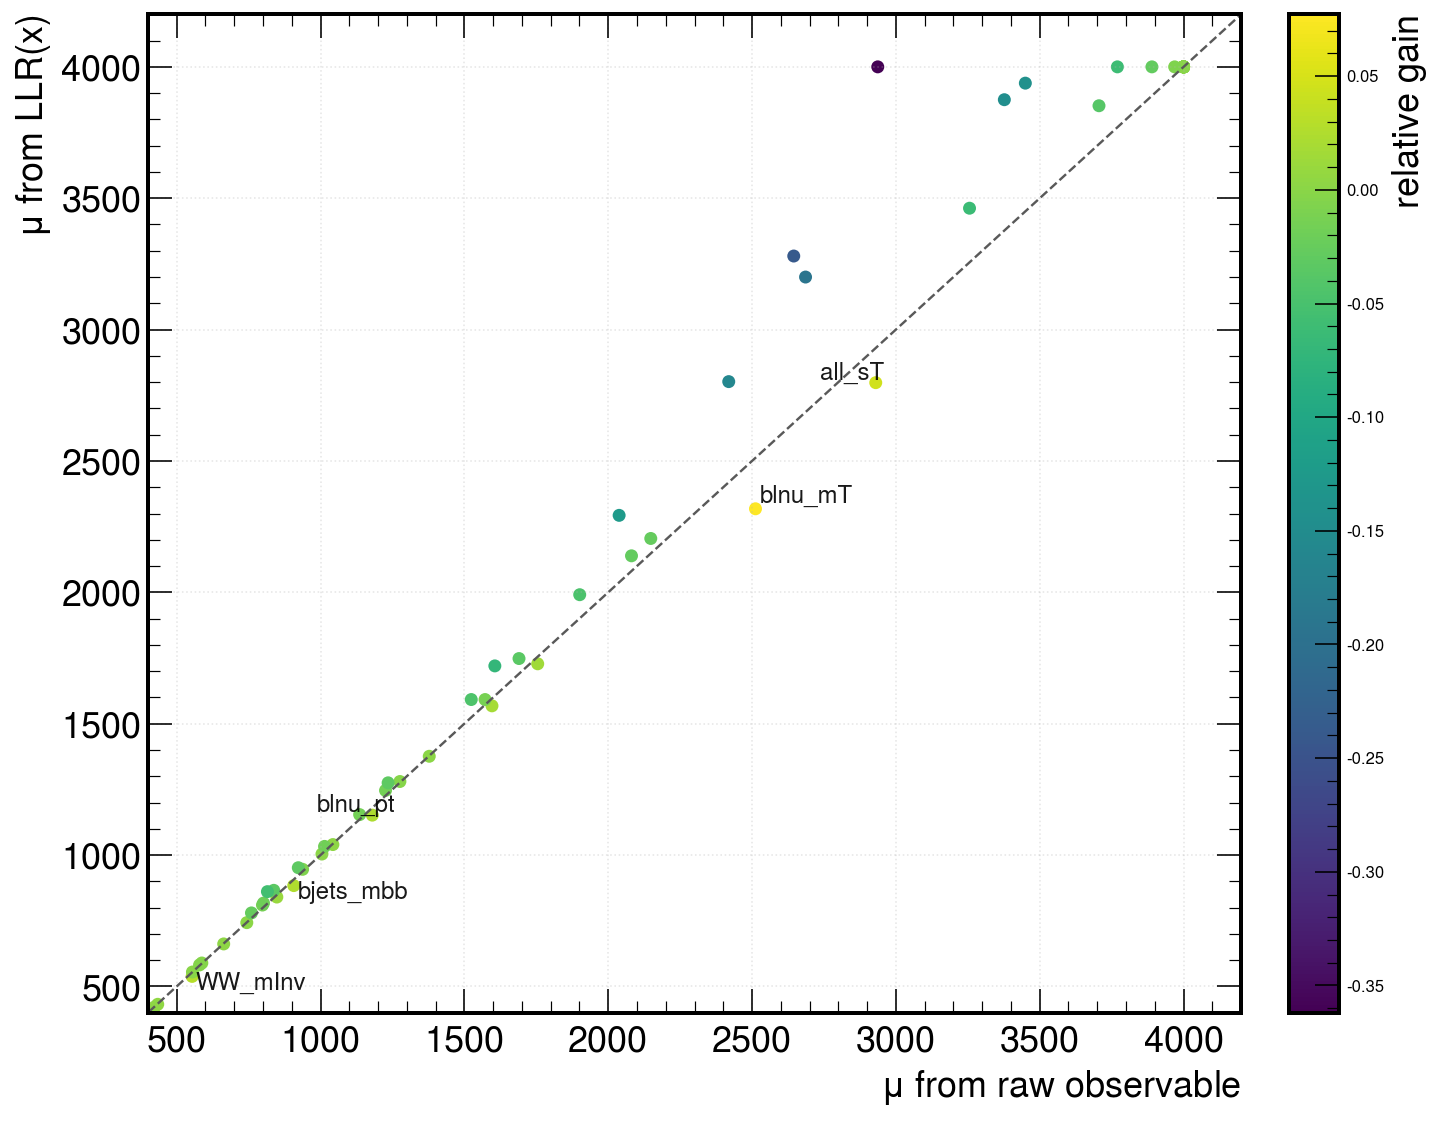

In [20]:
scatter_llr_vs_raw(diagnostics_df)